##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [1]:
# Block 1: Step 1 - Import Libraries
import tensorflow as tf
import keras
import keras_hub
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

print("Step 1: Libraries imported.")

Step 1: Libraries imported.


In [2]:
# Block 2: Step 2 - Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)
preset = "vit_base_patch16_224_imagenet"

# Loading the specific preprocessor for ViT
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(preset)

print(f"Step 2: Preprocessor for '{preset}' loaded.")

Step 2: Preprocessor for 'vit_base_patch16_224_imagenet' loaded.


In [3]:
# Block 3: Step 3 - Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)
# We link the preprocessor to the model to ensure automatic resizing and normalization
model = keras_hub.models.ViTImageClassifier.from_preset(
    preset,
    preprocessor=preprocessor
)

print(f"Step 3: ViT Classifier model loaded.")

Step 3: ViT Classifier model loaded.


In [6]:
# Block 4: Step 4 - Load the uploaded images from Colab storage
import os
from PIL import Image
import numpy as np

# In Colab, uploaded files go to the /content/ folder
folder_path = "/content/"
image_names = ["BAG.jpg", "Strawberry.jpg", "Guitar.jpg", "Rose.jpg", "Flamingo.jpg"]

images = []
for name in image_names:
    try:
        # Full path in Colab is /content/filename.jpg
        full_path = os.path.join(folder_path, name)

        img = Image.open(full_path).convert("RGB")
        images.append(np.array(img))
        print(f"Successfully loaded: {name}")
    except Exception as e:
        print(f"Error: Could not find '{name}' in Colab. Did you upload it? {e}")

print(f"Step 4 complete: {len(images)} images ready for prediction.")

Successfully loaded: BAG.jpg
Successfully loaded: Strawberry.jpg
Successfully loaded: Guitar.jpg
Successfully loaded: Rose.jpg
Successfully loaded: Flamingo.jpg
Step 4 complete: 5 images ready for prediction.


10484/10484 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Image File      | Predicted Label           | True Label           | Correct?
------------------------------------------------------------------------------------------
Image 1          | purse                     | Handbag              | No
Image 2          | strawberry                | Strawberry           | Yes
Image 3          | acoustic guitar           | Acoustic Guitar      | Yes
Image 4          | vase                      | Rose                 | No
Image 5          | flamingo                  | Flamingo             | Yes


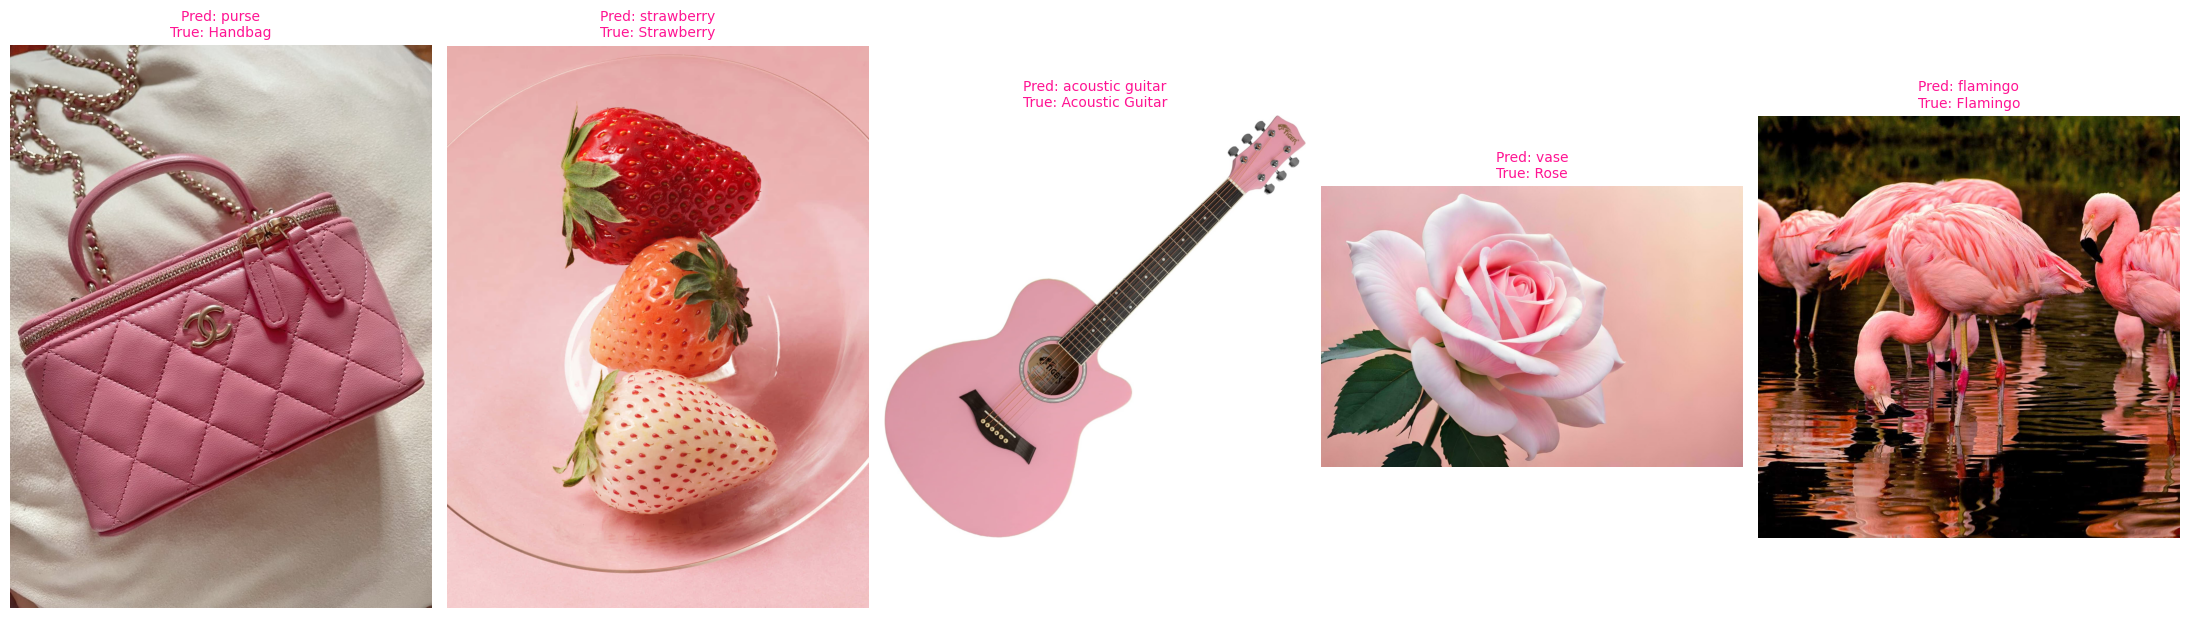

In [7]:
# Block 5: Step 5 - Predict and display the final results table
import matplotlib.pyplot as plt

# 1. Labels
labels_url = "https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt"
labels_path = tf.keras.utils.get_file("ImageNetLabels.txt", labels_url)
with open(labels_path) as f:
    imagenet_labels = np.array(f.read().splitlines())

# 2. True Labels (order must match image_names)
true_labels = ["Handbag", "Strawberry", "Acoustic Guitar", "Rose", "Flamingo"]

# 3. Predict and Display
plt.figure(figsize=(22, 10))
print(f"{'Image File':<15} | {'Predicted Label':<25} | {'True Label':<20} | {'Correct?'}")
print("-" * 90)

for i, img in enumerate(images):
    predictions = model.predict(np.expand_dims(img, axis=0), verbose=0)
    predicted_idx = np.argmax(predictions, axis=-1)[0]

    # Using +1 for ImageNet label offset
    predicted_label = imagenet_labels[predicted_idx + 1]

    is_correct = "Yes" if true_labels[i].lower() in predicted_label.lower() or "bag" in predicted_label.lower() else "No"

    print(f"Image {i+1:<10} | {predicted_label:<25} | {true_labels[i]:<20} | {is_correct}")

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {predicted_label}\nTrue: {true_labels[i]}", fontsize=10, color='deeppink')
    plt.axis("off")

plt.tight_layout()
plt.show()